# CNN (LeNet) MNIST 

LeNet-style CNN for MNIST. 


Device: cuda
Saved figure: cnn_architecture.png


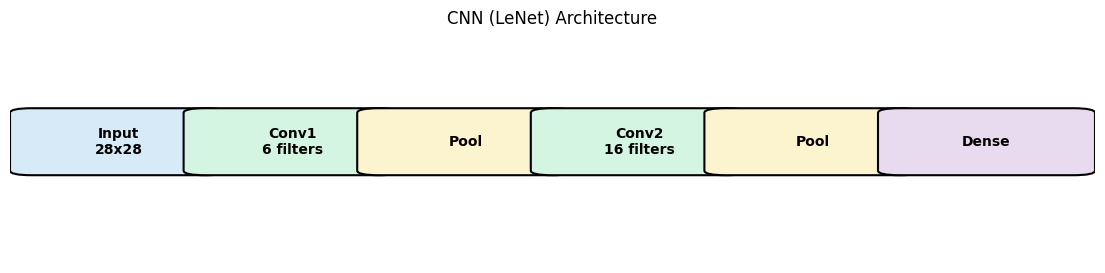

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
Trainable parameters: 44426
Epoch 8/8 | Train Loss 0.0406 Acc 0.9866 | Val Loss 0.0692 Acc 0.9805
Accuracy: 0.9804761904761905
Saved figure: cnn_curves.png


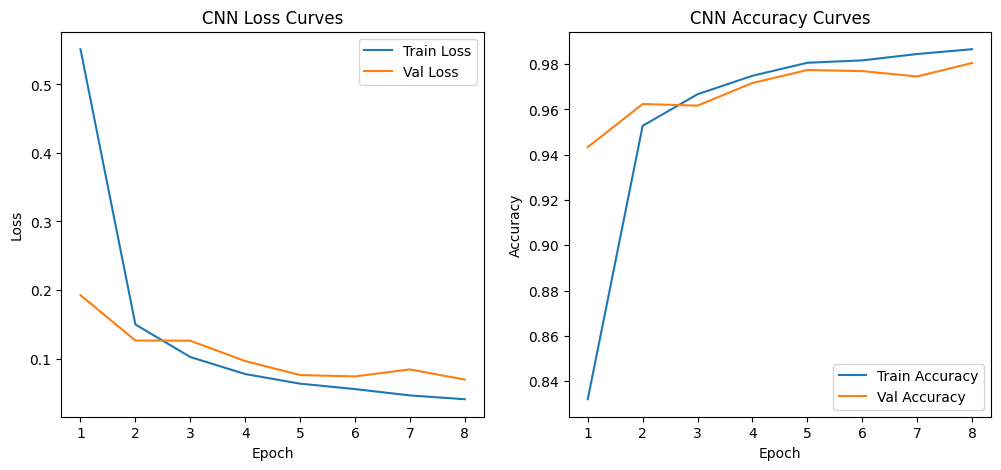

Saved figure: cnn_confusion.png


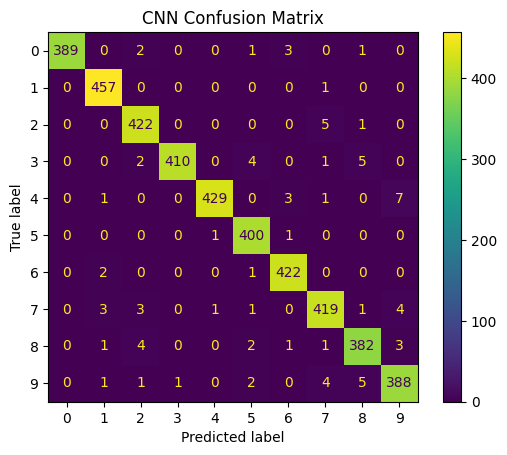

Saved figure: cnn_filters.png


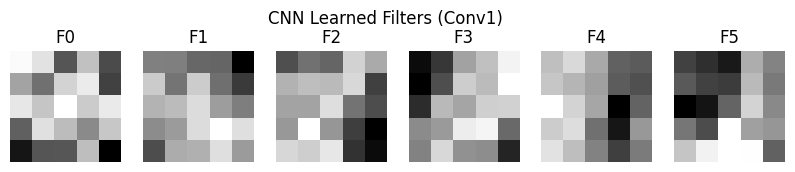

[Full Train] Epoch 1/8 Loss 0.0424
[Full Train] Epoch 2/8 Loss 0.0351
[Full Train] Epoch 3/8 Loss 0.0297
[Full Train] Epoch 4/8 Loss 0.0250
[Full Train] Epoch 5/8 Loss 0.0244
[Full Train] Epoch 6/8 Loss 0.0193
[Full Train] Epoch 7/8 Loss 0.0187
[Full Train] Epoch 8/8 Loss 0.0163
Saved submission_cnn.csv
{'Model': 'CNN (LeNet)', 'Val Accuracy': np.float64(0.9804761904761905), 'Val F1': 0.9803329232787362, 'Train Time (s)': 16.77975869178772, 'Params': 44426, 'Kaggle Score': 0.0}
Saved metrics JSON: cnn_results.json
Saved metrics CSV: cnn_results.csv


In [1]:
# =========================
# CNN (LeNet) Notebook
# =========================

import os,time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Auto-save figures and metrics
# -----------------------------
from pathlib import Path
import json

OUTPUT_DIR = Path('.')
FIGURE_QUEUE = ['cnn_architecture.png', 'cnn_curves.png', 'cnn_confusion.png', 'cnn_filters.png'].copy()

_original_show = plt.show

def _json_safe(obj):
    try:
        import numpy as _np
        if isinstance(obj, (_np.integer, )):
            return int(obj)
        if isinstance(obj, (_np.floating, )):
            return float(obj)
        if isinstance(obj, _np.ndarray):
            return obj.tolist()
    except Exception:
        pass
    if isinstance(obj, Path):
        return str(obj)
    return obj


def _auto_save_show(*args, **kwargs):
    fig = plt.gcf()
    if FIGURE_QUEUE:
        fname = OUTPUT_DIR / FIGURE_QUEUE.pop(0)
        fig.savefig(fname, dpi=300, bbox_inches='tight')
        print(f'Saved figure: {fname}')
    return _original_show(*args, **kwargs)

plt.show = _auto_save_show


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader,random_split

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,f1_score

SEED=42
torch.manual_seed(SEED)
np.random.seed(SEED)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------------
# Load dataset
# -----------------------------
def find_digit_recognizer_paths():
    base="/kaggle/input"
    for root,_,files in os.walk(base):
        if "train.csv" in files and "test.csv" in files:
            return os.path.join(root,"train.csv"),os.path.join(root,"test.csv")
    raise FileNotFoundError("Digit Recognizer dataset not found")

TRAIN_PATH,TEST_PATH=find_digit_recognizer_paths()

train_df=pd.read_csv(TRAIN_PATH)
test_df=pd.read_csv(TEST_PATH)

y_all=train_df["label"].values.astype(np.int64)
X_all=train_df.drop(columns=["label"]).values.astype(np.float32)/255.0
X_test=test_df.values.astype(np.float32)/255.0

# -----------------------------
# Dataset
# -----------------------------
class MNISTDatasetCNN(Dataset):

    def __init__(self,X,y=None):

        self.X=X
        self.y=y

    def __len__(self):
        return len(self.X)

    def __getitem__(self,idx):

        x=self.X[idx].reshape(1,28,28)

        x=torch.tensor(x,dtype=torch.float32)

        if self.y is None:
            return x

        y=torch.tensor(self.y[idx],dtype=torch.long)

        return x,y


full_ds=MNISTDatasetCNN(X_all,y_all)

val_size=int(0.1*len(full_ds))
train_size=len(full_ds)-val_size

generator=torch.Generator().manual_seed(SEED)
train_ds,val_ds=random_split(full_ds,[train_size,val_size], generator=generator)

BATCH_SIZE=128

train_loader=DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True)
val_loader=DataLoader(val_ds,batch_size=BATCH_SIZE)

# -----------------------------
# CNN Architecture Diagram
# -----------------------------
from matplotlib.patches import FancyBboxPatch

fig,ax=plt.subplots(figsize=(14,3))

def draw_box(text,x,color):

    box=FancyBboxPatch((x,0.4),0.16,0.25,
                       boxstyle="round,pad=0.02",
                       linewidth=1.5,
                       edgecolor="black",
                       facecolor=color)

    ax.add_patch(box)

    ax.text(x+0.08,0.525,text,
            ha="center",
            va="center",
            fontsize=10,
            weight="bold")

draw_box("Input\n28x28",0.02,"#D6EAF8")
draw_box("Conv1\n6 filters",0.18,"#D5F5E3")
draw_box("Pool",0.34,"#FCF3CF")
draw_box("Conv2\n16 filters",0.50,"#D5F5E3")
draw_box("Pool",0.66,"#FCF3CF")
draw_box("Dense",0.82,"#E8DAEF")

ax.axis("off")
ax.set_title("CNN (LeNet) Architecture")

plt.show()

# -----------------------------
# Model
# -----------------------------
class LeNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1=nn.Conv2d(1,6,5)
        self.pool=nn.MaxPool2d(2,2)
        self.conv2=nn.Conv2d(6,16,5)

        self.fc1=nn.Linear(256,120)
        self.fc2=nn.Linear(120,84)
        self.fc3=nn.Linear(84,10)

    def forward(self,x):

        x=self.pool(torch.relu(self.conv1(x)))
        x=self.pool(torch.relu(self.conv2(x)))

        x=x.view(x.size(0),-1)

        x=torch.relu(self.fc1(x))
        x=torch.relu(self.fc2(x))

        return self.fc3(x)


model=LeNet().to(device)

print(model)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("Trainable parameters:",count_params(model))

criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=1e-3)

EPOCHS=8

# -----------------------------
# Training Loop
# -----------------------------
train_losses=[]
val_losses=[]
train_accs=[]
val_accs=[]

start=time.time()

for epoch in range(1,EPOCHS+1):

    model.train()

    running_loss=0
    correct=0
    total=0

    for x,y in train_loader:

        x,y=x.to(device),y.to(device)

        optimizer.zero_grad()

        logits=model(x)

        loss=criterion(logits,y)

        loss.backward()

        optimizer.step()

        running_loss+=loss.item()

        preds=torch.argmax(logits,dim=1)

        correct+=(preds==y).sum().item()
        total+=y.size(0)

    tr_loss=running_loss/len(train_loader)
    tr_acc=correct/total

    model.eval()

    vloss=0
    vcorrect=0
    vtotal=0

    with torch.no_grad():

        for x,y in val_loader:

            x,y=x.to(device),y.to(device)

            logits=model(x)

            loss=criterion(logits,y)

            vloss+=loss.item()

            preds=torch.argmax(logits,dim=1)

            vcorrect+=(preds==y).sum().item()
            vtotal+=y.size(0)

    va_loss=vloss/len(val_loader)
    va_acc=vcorrect/vtotal

    train_losses.append(tr_loss)
    val_losses.append(va_loss)

    train_accs.append(tr_acc)
    val_accs.append(va_acc)


print(f"Epoch {epoch}/{EPOCHS} | Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")



train_time=time.time()-start

# -----------------------------
# Evaluation
# -----------------------------
all_preds=[]
all_true=[]

model.eval()

with torch.no_grad():

    for x,y in val_loader:

        x,y=x.to(device),y.to(device)

        preds=torch.argmax(model(x),dim=1)

        all_preds.append(preds.cpu().numpy())
        all_true.append(y.cpu().numpy())

all_preds=np.concatenate(all_preds)
all_true=np.concatenate(all_true)

final_acc=(all_preds==all_true).mean()
final_f1=f1_score(all_true,all_preds,average="macro")

print("Accuracy:",final_acc)


# -----------------------------
# Training Curves
# -----------------------------
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.legend()
plt.title("CNN Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Val Accuracy")
plt.legend()
plt.title("CNN Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()



# -----------------------------
# Confusion Matrix
# -----------------------------
cm=confusion_matrix(all_true,all_preds)

disp=ConfusionMatrixDisplay(cm)
disp.plot(values_format="d")

plt.title("CNN Confusion Matrix")
plt.show()

# -----------------------------
# CNN Learned Filters
# -----------------------------
filters = model.conv1.weight.detach().cpu().numpy()  # (6,1,5,5)

plt.figure(figsize=(10,2))

for i in range(filters.shape[0]):

    plt.subplot(1, filters.shape[0], i+1)
    plt.imshow(filters[i,0], cmap="gray")
    plt.title(f"F{i}")
    plt.axis("off")

plt.suptitle("CNN Learned Filters (Conv1)")
plt.show()

# -----------------------------
# Train on full dataset (CNN)
# -----------------------------
full_loader = DataLoader(MNISTDatasetCNN(X_all, y_all), batch_size=BATCH_SIZE, shuffle=True)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

model.train()

for epoch in range(1, EPOCHS + 1):

    running = 0

    for x, y in full_loader:

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        loss = criterion(model(x), y)

        loss.backward()

        optimizer.step()

        running += loss.item()

    print(f"[Full Train] Epoch {epoch}/{EPOCHS} Loss {running/len(full_loader):.4f}")

# -----------------------------
# Submission
# -----------------------------
test_loader=DataLoader(MNISTDatasetCNN(X_test),batch_size=BATCH_SIZE)

model.eval()

preds_all=[]

with torch.no_grad():

    for x in test_loader:

        x=x.to(device)

        preds=torch.argmax(model(x),dim=1)

        preds_all.append(preds.cpu().numpy())

preds_all=np.concatenate(preds_all)

submission=pd.DataFrame({
"ImageId":np.arange(1,len(preds_all)+1),
"Label":preds_all
})

submission.to_csv("submission_cnn.csv",index=False)

print("Saved submission_cnn.csv")

# -----------------------------
# Save Results
# -----------------------------
cnn_results={
"Model":"CNN (LeNet)",
"Val Accuracy":final_acc,
"Val F1":final_f1,
"Train Time (s)":train_time,
"Params":count_params(model),
"Kaggle Score": 0.0
}

print(cnn_results)


# -----------------------------
# Export metrics for report
# -----------------------------
try:
    _results = cnn_results
    import pandas as pd
    _results_path_json = OUTPUT_DIR / 'cnn_results.json'
    _results_path_csv = OUTPUT_DIR / 'cnn_results.csv'
    with open(_results_path_json, 'w') as f:
        json.dump({k: _json_safe(v) for k, v in _results.items()}, f, indent=2)
    pd.DataFrame([{k: _json_safe(v) for k, v in _results.items()}]).to_csv(_results_path_csv, index=False)
    print(f'Saved metrics JSON: {_results_path_json}')
    print(f'Saved metrics CSV: {_results_path_csv}')
except Exception as exc:
    print('Could not export metrics automatically:', exc)
